I0000 00:00:1782570788.388592 3272096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782570788.431159 3272096 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782570794.502760 3272096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Notebook directory: /home/rameyjm7/workspace/ML-wireless-signal-classification/notebooks
Project root: /home/rameyjm7/workspace/ML-wireless-signal-classification
Outputs dir: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison
Loading DeepRadar2022 from: /scratch/rameyjm7/datasets/DeepRadar2022
Loading model from: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/deepradar2022/deepradar2022_cnn_bilstm_final.keras


I0000 00:00:1782570810.243922 3272096 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 140829 MB memory:  -> device: 0, name: NVIDIA H200, pci bus id: 0000:19:00.0, compute capability: 9.0a
E0000 00:00:1782570811.057066 3273965 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
/home/rameyjm7/workspace/ml-env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1782570813.607708 3273846 cuda_dnn.cc:461] Loaded cuDNN version 91002



✅ Model Test Accuracy (all SNRs): 84.33%


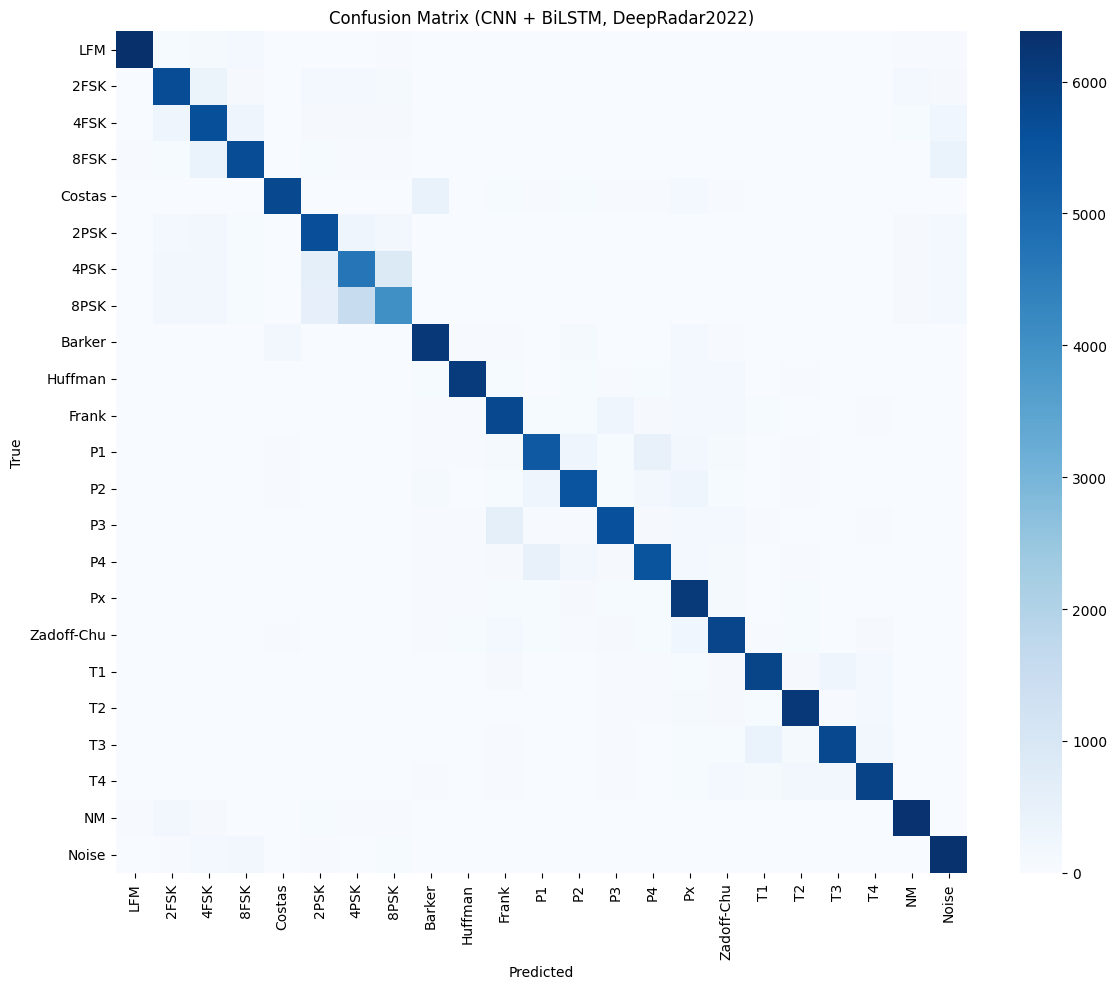


Classification Report (All SNRs):
              precision    recall  f1-score   support

         LFM       0.97      0.94      0.96      6800
        2FSK       0.82      0.84      0.83      6800
        4FSK       0.77      0.83      0.80      6800
        8FSK       0.86      0.84      0.85      6800
      Costas       0.93      0.85      0.89      6800
        2PSK       0.79      0.83      0.81      6800
        4PSK       0.68      0.69      0.68      6800
        8PSK       0.74      0.59      0.66      6800
      Barker       0.88      0.91      0.89      6800
     Huffman       0.94      0.90      0.92      6800
       Frank       0.80      0.85      0.83      6800
          P1       0.83      0.79      0.81      6800
          P2       0.84      0.81      0.83      6800
          P3       0.86      0.82      0.84      6800
          P4       0.82      0.81      0.81      6800
          Px       0.76      0.90      0.83      6800
  Zadoff-Chu       0.82      0.86      0.84   

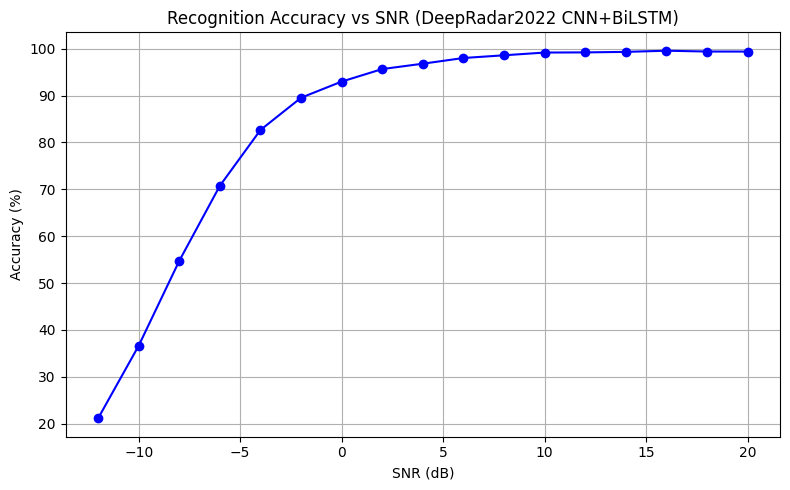

Saved line charts: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_deepradar2022_accuracy_vs_snr_line_plots.png


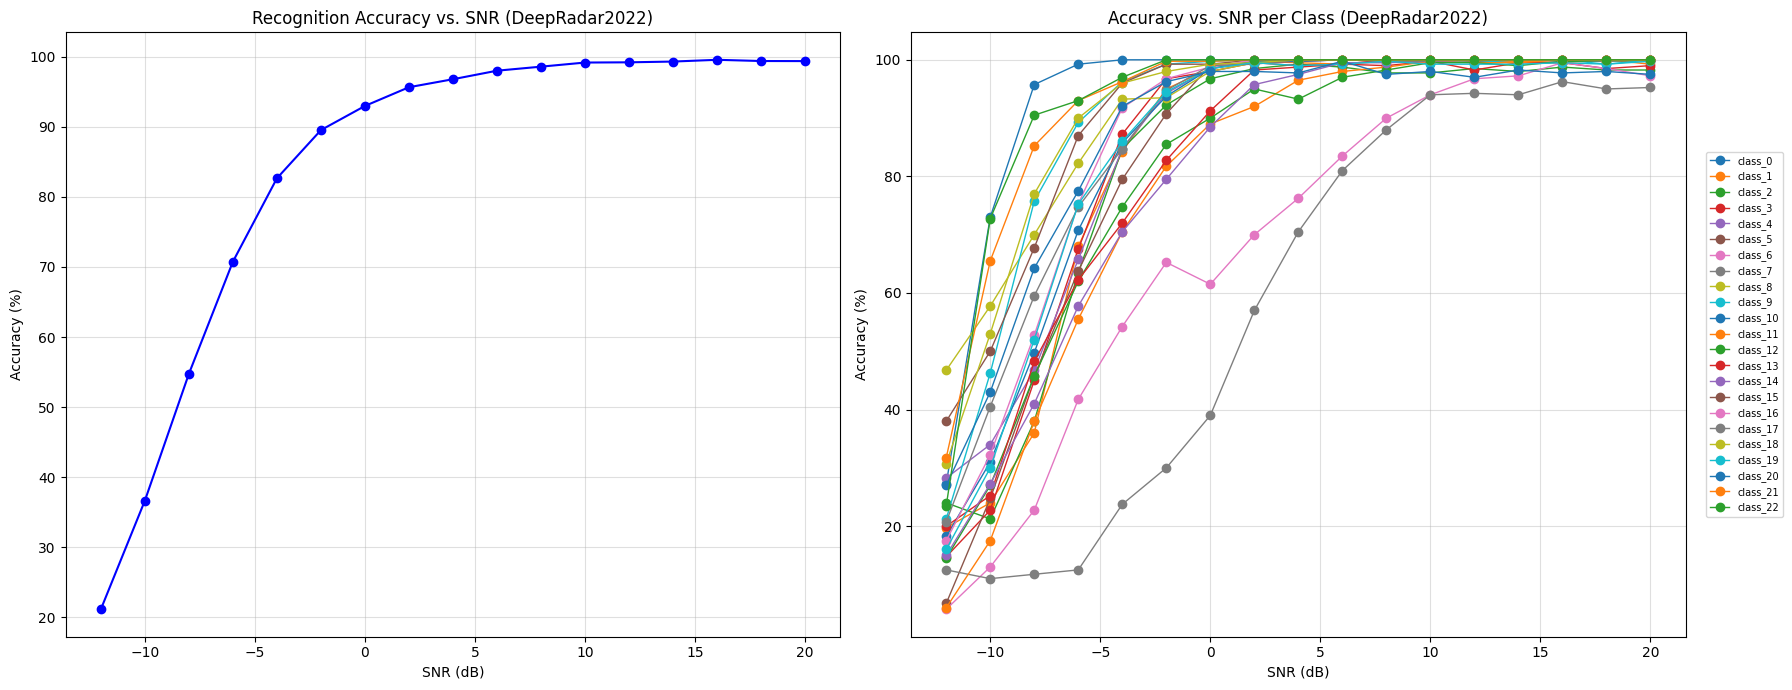

In [1]:
# Cell 1: TEST - DeepRadar2022 model evaluation
# https://www.kaggle.com/jacobramey
# https://github.com/rameyjm7

import os
import numpy as np
import h5py, scipy.io as sio
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model
from pathlib import Path
import yaml

# ------------------------------
# Resolve notebook directory safely
# ------------------------------
notebook_dir = Path().resolve()
project_root = notebook_dir.parent

print(f"Notebook directory: {notebook_dir}")
print(f"Project root: {project_root}")
outputs_dir_50 = project_root / "outputs" / "50_evaluation_comparison"
outputs_dir_50.mkdir(parents=True, exist_ok=True)
print(f"Outputs dir: {outputs_dir_50}")

# ------------------------------
# Load DeepRadar2022 dataset
# ------------------------------
cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    path = Path(local_cfg.get('dataset_root', '/scratch/rameyjm7/datasets')) / 'DeepRadar2022'
else:
    path = Path('/scratch/rameyjm7/datasets/DeepRadar2022')
print(f"Loading DeepRadar2022 from: {path}")

def load_h5(filepath, key):
    with h5py.File(filepath, "r") as f:
        return np.array(f[key], dtype="float32").T

def load_mat(filepath, key):
    d = sio.loadmat(filepath)
    return d[key]

X_test  = load_h5(path / "X_test.mat", "X_test")
Y_test  = load_mat(path / "Y_test.mat", "Y_test")
lbl_test = load_mat(path / "lbl_test.mat", "lbl_test")

# Extract modulation class and SNR
cls_test, snr_test = lbl_test[:,0].astype(int)-1, lbl_test[:,1]

# ------------------------------
# Normalize IQ per sample
# ------------------------------
def normalize_iq(X):
    Xn = np.empty_like(X)
    for i in range(X.shape[0]):
        scale = np.max(np.abs(X[i])) + 1e-12
        Xn[i] = X[i] / scale
    return Xn

X_test = normalize_iq(X_test)

# ------------------------------
# Append SNR as a third channel
# ------------------------------
def append_snr_feature(X, snr):
    X_out = []
    for i in range(X.shape[0]):
        snr_col = np.full((X.shape[1], 1), snr[i] / 20.0)
        X_out.append(np.concatenate([X[i], snr_col], axis=1))
    return np.array(X_out, dtype=np.float32)

X_test = append_snr_feature(X_test, snr_test)

# ------------------------------
# Load pre-trained model
# ------------------------------
model_path = project_root / "models" / "deepradar2022" / "deepradar2022_cnn_bilstm_final.keras"
print(f"Loading model from: {model_path}")
model = load_model(model_path)

# ------------------------------
# Evaluate model
# ------------------------------
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n✅ Model Test Accuracy (all SNRs): {acc*100:.2f}%")

# ------------------------------
# Predictions and metrics
# ------------------------------
Y_pred = model.predict(X_test, verbose=0)
y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(Y_pred, axis=1)

# ------------------------------
# Confusion Matrix
# ------------------------------
labels = [
    "LFM", "2FSK", "4FSK", "8FSK", "Costas", "2PSK", "4PSK", "8PSK",
    "Barker", "Huffman", "Frank", "P1", "P2", "P3", "P4", "Px",
    "Zadoff-Chu", "T1", "T2", "T3", "T4", "NM", "Noise"
]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", cbar=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CNN + BiLSTM, DeepRadar2022)")
plt.tight_layout()
plt.show()

print("\nClassification Report (All SNRs):")
print(classification_report(y_true, y_pred, target_names=labels))

# ------------------------------
# Accuracy vs SNR
# ------------------------------
unique_snrs = sorted(np.unique(snr_test))
acc_snr = []
for snr in unique_snrs:
    idx = np.where(snr_test == snr)[0]
    acc_snr.append(accuracy_score(y_true[idx], y_pred[idx]) * 100)

plt.figure(figsize=(8,5))
plt.plot(unique_snrs, acc_snr, 'b-o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Recognition Accuracy vs SNR (DeepRadar2022 CNN+BiLSTM)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------
# Accuracy vs SNR per class (DeepRadar2022)
# ------------------------------
class_ids = np.array(sorted(np.unique(y_true)), dtype=int)
per_class_acc = np.full((len(class_ids), len(unique_snrs)), np.nan, dtype=np.float32)
for i, cls in enumerate(class_ids):
    cls_mask = y_true == cls
    for j, snr in enumerate(unique_snrs):
        idx = np.where((snr_test == snr) & cls_mask)[0]
        if len(idx) > 0:
            per_class_acc[i, j] = accuracy_score(y_true[idx], y_pred[idx]) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].plot(unique_snrs, acc_snr, marker='o', color='blue')
axes[0].set_title('Recognition Accuracy vs. SNR (DeepRadar2022)')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(True, alpha=0.4)

for i, cls in enumerate(class_ids):
    axes[1].plot(unique_snrs, per_class_acc[i], marker='o', linewidth=1.0, label=f'class_{cls}')
axes[1].set_title('Accuracy vs. SNR per Class (DeepRadar2022)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7)
plt.tight_layout()

png = outputs_dir_50 / '50_deepradar2022_accuracy_vs_snr_line_plots.png'
plt.savefig(png, dpi=180)
print('Saved line charts:', png)
plt.show()



Resolved model path: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2016/rml2016_lstm_rnn_2024.keras
Model loaded successfully.
Outputs dir: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison
Loading dataset: /scratch/rameyjm7/datasets/RML2016/RML2016.10a_dict.pkl


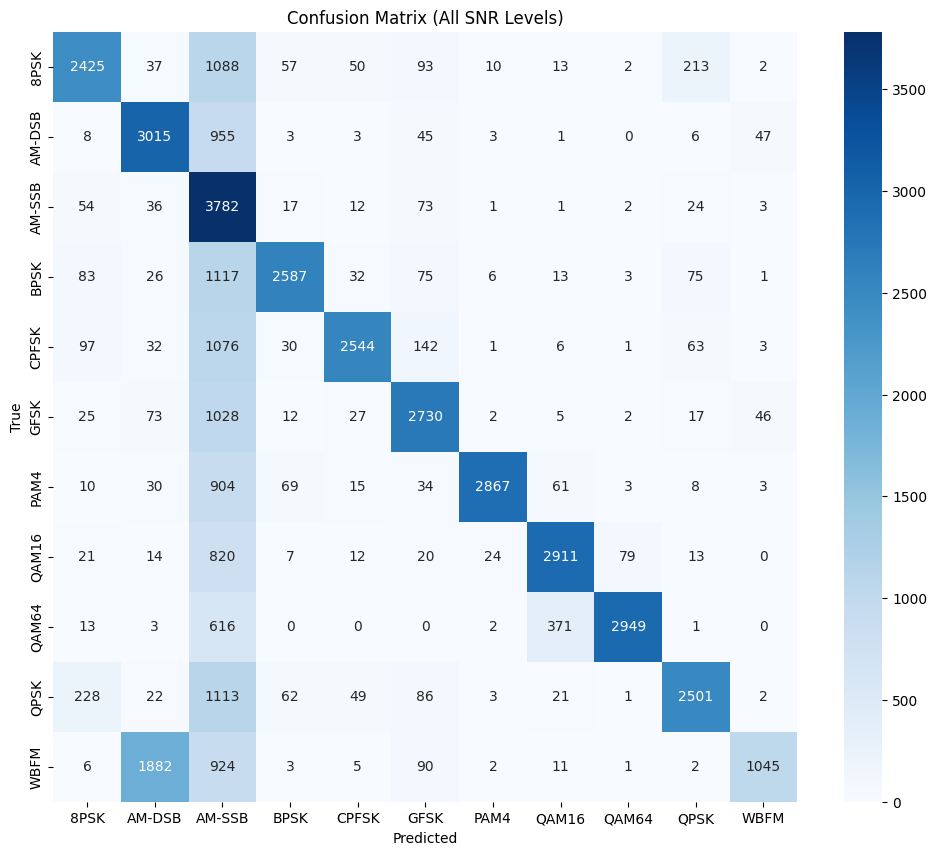


Classification Report (All SNR Levels):
              precision    recall  f1-score   support

        8PSK       0.82      0.61      0.70      3990
      AM-DSB       0.58      0.74      0.65      4086
      AM-SSB       0.28      0.94      0.43      4005
        BPSK       0.91      0.64      0.75      4018
       CPFSK       0.93      0.64      0.75      3995
        GFSK       0.81      0.69      0.74      3967
        PAM4       0.98      0.72      0.83      4004
       QAM16       0.85      0.74      0.79      3921
       QAM64       0.97      0.75      0.84      3955
        QPSK       0.86      0.61      0.71      4088
        WBFM       0.91      0.26      0.41      3971

    accuracy                           0.67     44000
   macro avg       0.81      0.67      0.69     44000
weighted avg       0.81      0.67      0.69     44000


Samples with SNR > 5 dB: 15332


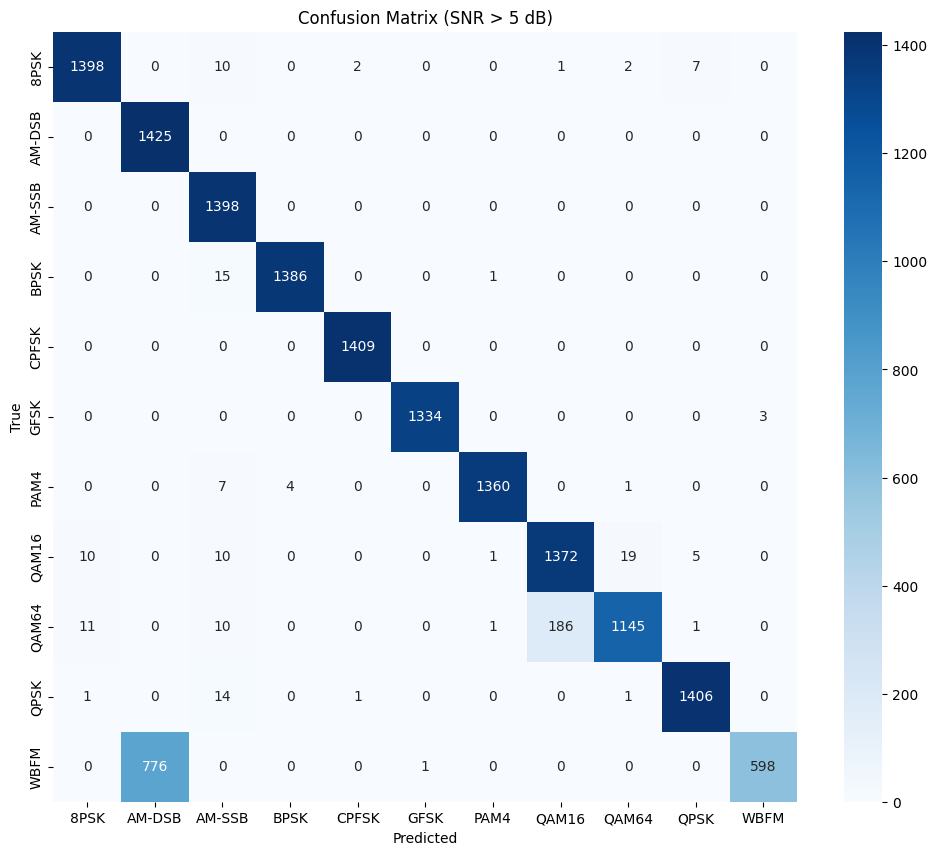


Classification Report (SNR > 5 dB):
              precision    recall  f1-score   support

        8PSK       0.98      0.98      0.98      1420
      AM-DSB       0.65      1.00      0.79      1425
      AM-SSB       0.95      1.00      0.98      1398
        BPSK       1.00      0.99      0.99      1402
       CPFSK       1.00      1.00      1.00      1409
        GFSK       1.00      1.00      1.00      1337
        PAM4       1.00      0.99      0.99      1372
       QAM16       0.88      0.97      0.92      1417
       QAM64       0.98      0.85      0.91      1354
        QPSK       0.99      0.99      0.99      1423
        WBFM       1.00      0.43      0.61      1375

    accuracy                           0.93     15332
   macro avg       0.95      0.93      0.92     15332
weighted avg       0.95      0.93      0.92     15332

Saved line charts: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_rml2016_accuracy_vs_snr_line_plots.p

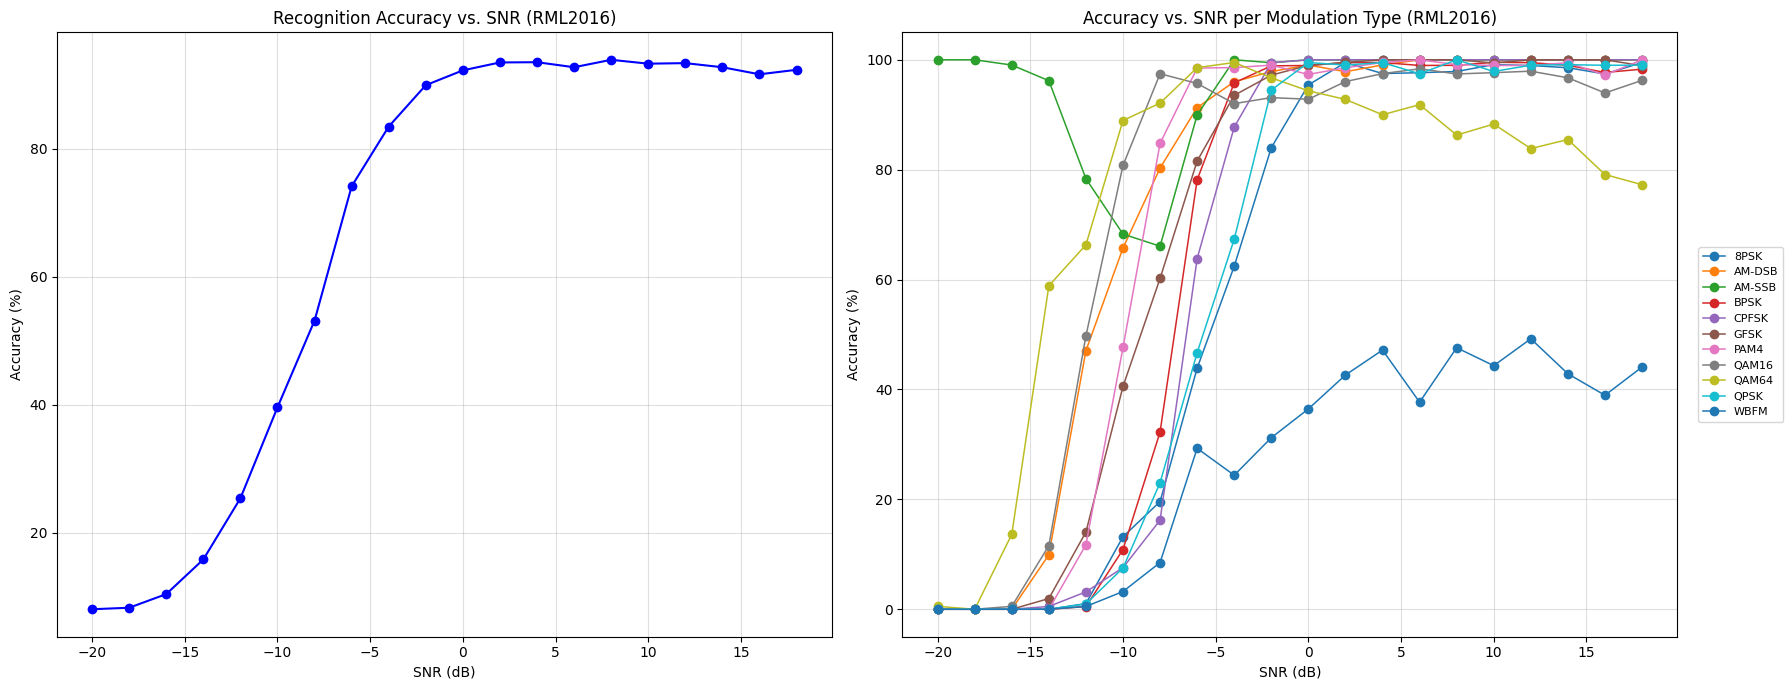

In [2]:
# Cell 2: TEST - RML2016 model evaluation
# https://www.kaggle.com/jacobramey
# https://github.com/rameyjm7

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
import tensorflow as tf
import os
import yaml

# --------------------------------------------------------------
# Resolve model path
# --------------------------------------------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_path = os.path.join(project_root, "models", "rml2016", "rml2016_lstm_rnn_2024.keras")

print("Resolved model path:", model_path)
assert os.path.exists(model_path), f"Model file not found: {model_path}"

model = load_model(model_path)
print("Model loaded successfully.")
outputs_dir_50 = Path(project_root) / "outputs" / "50_evaluation_comparison"
outputs_dir_50.mkdir(parents=True, exist_ok=True)
print("Outputs dir:", outputs_dir_50)

# --------------------------------------------------------------
# Load RML2016.10a Dataset
# --------------------------------------------------------------
cfg_path = Path(project_root) / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    pkl_path = local_cfg.get('datasets', {}).get('rml2016', {}).get('pkl', '/scratch/rameyjm7/datasets/RML2016/RML2016.10a_dict.pkl')
else:
    pkl_path = '/scratch/rameyjm7/datasets/RML2016/RML2016.10a_dict.pkl'
print("Loading dataset:", pkl_path)

with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# --------------------------------------------------------------
# Prepare Data (your exact provided format)
# --------------------------------------------------------------
def prepare_data(data):
    X, y, snrs = [], [], []

    for (mod_type, snr), signals in data.items():
        for signal in signals:
            # IQ: shape (128, 2)
            iq = np.vstack([signal[0], signal[1]]).T

            # SNR feature channel (raw SNR, consistent with your training format)
            snr_col = np.full((128, 1), snr, dtype=np.float32)

            combined = np.hstack([iq, snr_col])  # (128, 3)

            X.append(combined)
            y.append(mod_type)
            snrs.append(snr)   # keep real SNR for analysis

    X = np.array(X)
    y = np.array(y)
    snrs = np.array(snrs)

    # Encode labels
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    # Train/test split
    X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
        X, y_encoded, snrs, test_size=0.2, random_state=42
    )

    # LSTM requires this shape already (128, 3)
    return X_train, X_test, y_train, y_test, snr_train, snr_test, encoder

# Prepare
X_train, X_test, y_train, y_test, snr_train, snr_test, encoder = prepare_data(data)

# --------------------------------------------------------------
# Evaluate model on full test set
# --------------------------------------------------------------
y_pred = np.argmax(model.predict(X_test, verbose=False), axis=1)

# Confusion matrix (ALL SNR)
cm_all = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (All SNR Levels)")
plt.show()

print("\nClassification Report (All SNR Levels):")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# --------------------------------------------------------------
# Evaluate only SNR > 5 dB subset
# --------------------------------------------------------------
idx_high = np.where(snr_test > 5)[0]

X_high = X_test[idx_high]
y_high = y_test[idx_high]

print(f"\nSamples with SNR > 5 dB: {len(idx_high)}")

y_pred_high = np.argmax(model.predict(X_high, verbose=False), axis=1)

cm_high = confusion_matrix(y_high, y_pred_high)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_high, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (SNR > 5 dB)")
plt.show()

print("\nClassification Report (SNR > 5 dB):")
print(classification_report(y_high, y_pred_high, target_names=encoder.classes_))



# --------------------------------------------------------------
# Accuracy vs SNR charts (RML2016)
# --------------------------------------------------------------
unique_snrs = np.array(sorted(np.unique(snr_test)), dtype=int)
overall_acc = []
per_mod_acc = np.full((len(encoder.classes_), len(unique_snrs)), np.nan, dtype=np.float32)

for j, snr in enumerate(unique_snrs):
    idx = np.where(snr_test == snr)[0]
    overall_acc.append(float(np.mean(y_pred[idx] == y_test[idx])) * 100.0)

for c in range(len(encoder.classes_)):
    cls_mask = y_test == c
    for j, snr in enumerate(unique_snrs):
        idx = np.where((snr_test == snr) & cls_mask)[0]
        if len(idx) > 0:
            per_mod_acc[c, j] = float(np.mean(y_pred[idx] == y_test[idx])) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].plot(unique_snrs, overall_acc, marker='o', color='blue')
axes[0].set_title('Recognition Accuracy vs. SNR (RML2016)')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(True, alpha=0.4)

for i, mod in enumerate(encoder.classes_):
    axes[1].plot(unique_snrs, per_mod_acc[i], marker='o', linewidth=1.1, label=mod)
axes[1].set_title('Accuracy vs. SNR per Modulation Type (RML2016)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()

png = outputs_dir_50 / '50_rml2016_accuracy_vs_snr_line_plots.png'
plt.savefig(png, dpi=180)
print('Saved line charts:', png)
plt.show()



RML2018 dataset: /scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5
RML2018 model: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/rml2018_lstm_rnn.keras
Outputs dir: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison
X_eval shape: (4800, 1024, 3)
max_snr used: 30
RML2018 mapping calibration: acc_orig=0.0192, acc_fixed=0.0994, acc_le=0.9465
Using mapping: labelencoder
RML2018 evaluation accuracy: 0.9465
              precision    recall  f1-score   support

     128APSK       0.93      0.92      0.92       200
      128QAM       0.95      0.93      0.94       200
      16APSK       0.98      0.98      0.98       200
       16PSK       1.00      1.00      1.00       200
       16QAM       1.00      1.00      1.00       200
      256QAM       0.95      0.82      0.88       200
      32APSK       1.00      1.00      1.00       200
       32PSK       1.00      1.00      1.00       200
       32QAM       0.98    

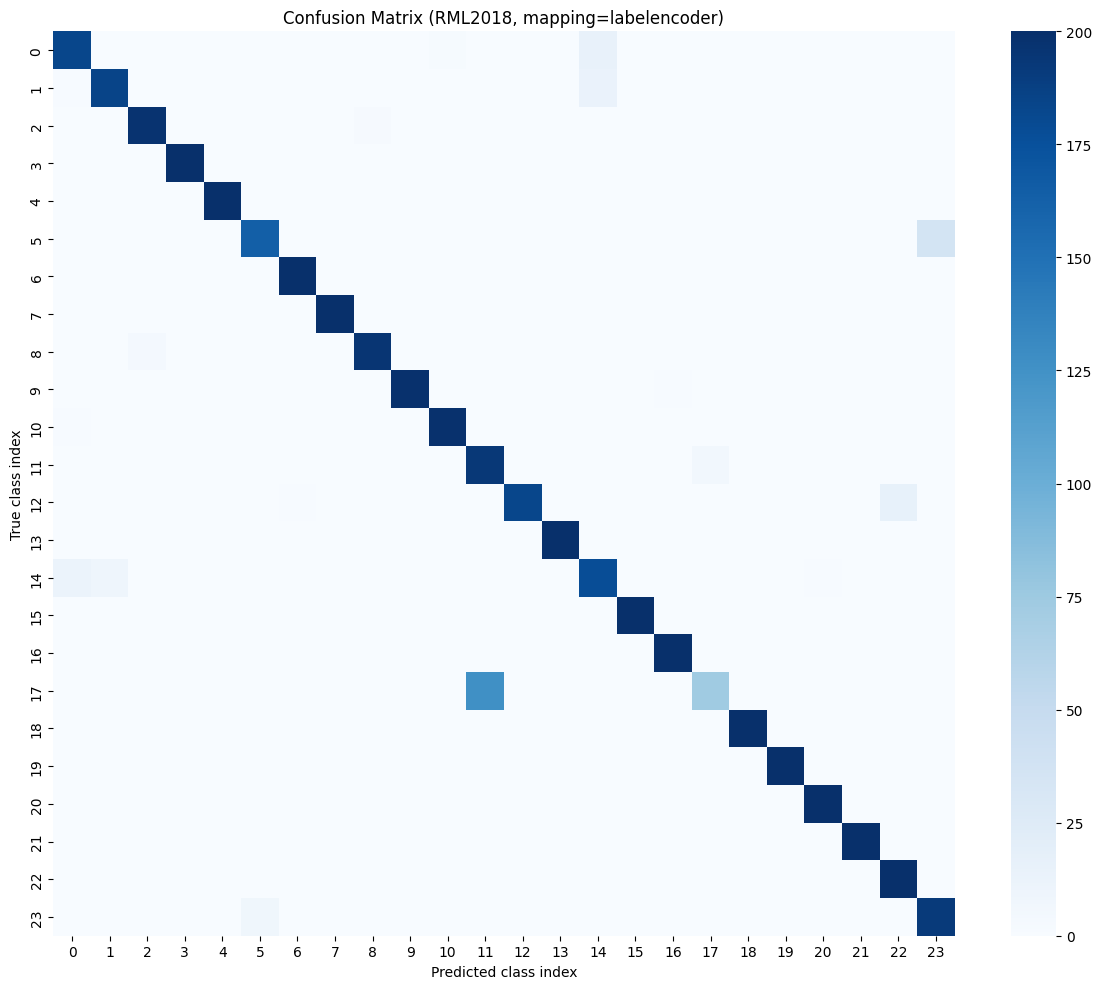

Using history file: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/rml2018/rml2018_cnn_transformer_baseline.continued.history.json
Saved training curves: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_rml2018_continuation_training_curves.png


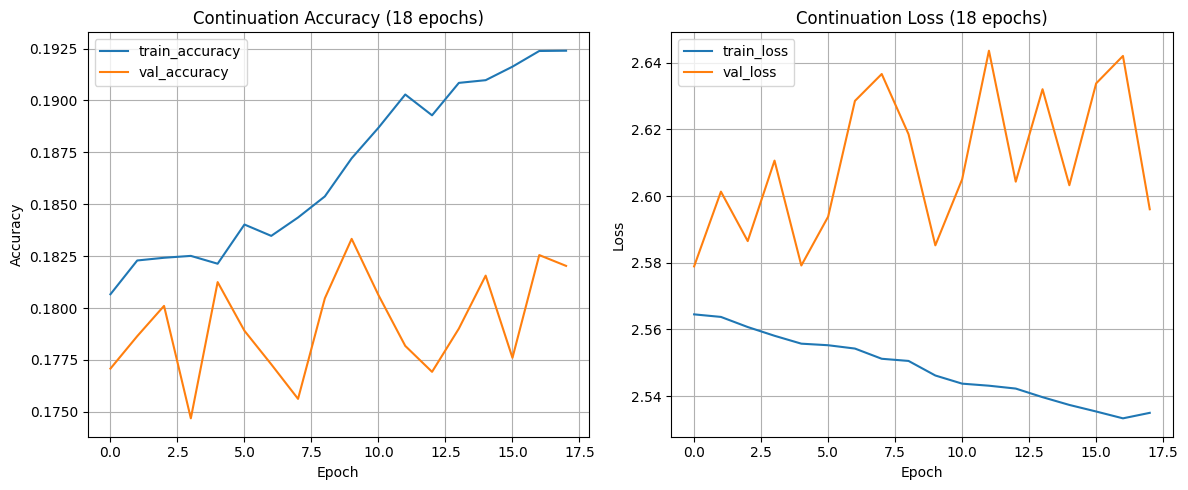

Saved line charts: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_rml2018_accuracy_vs_snr_line_plots.png


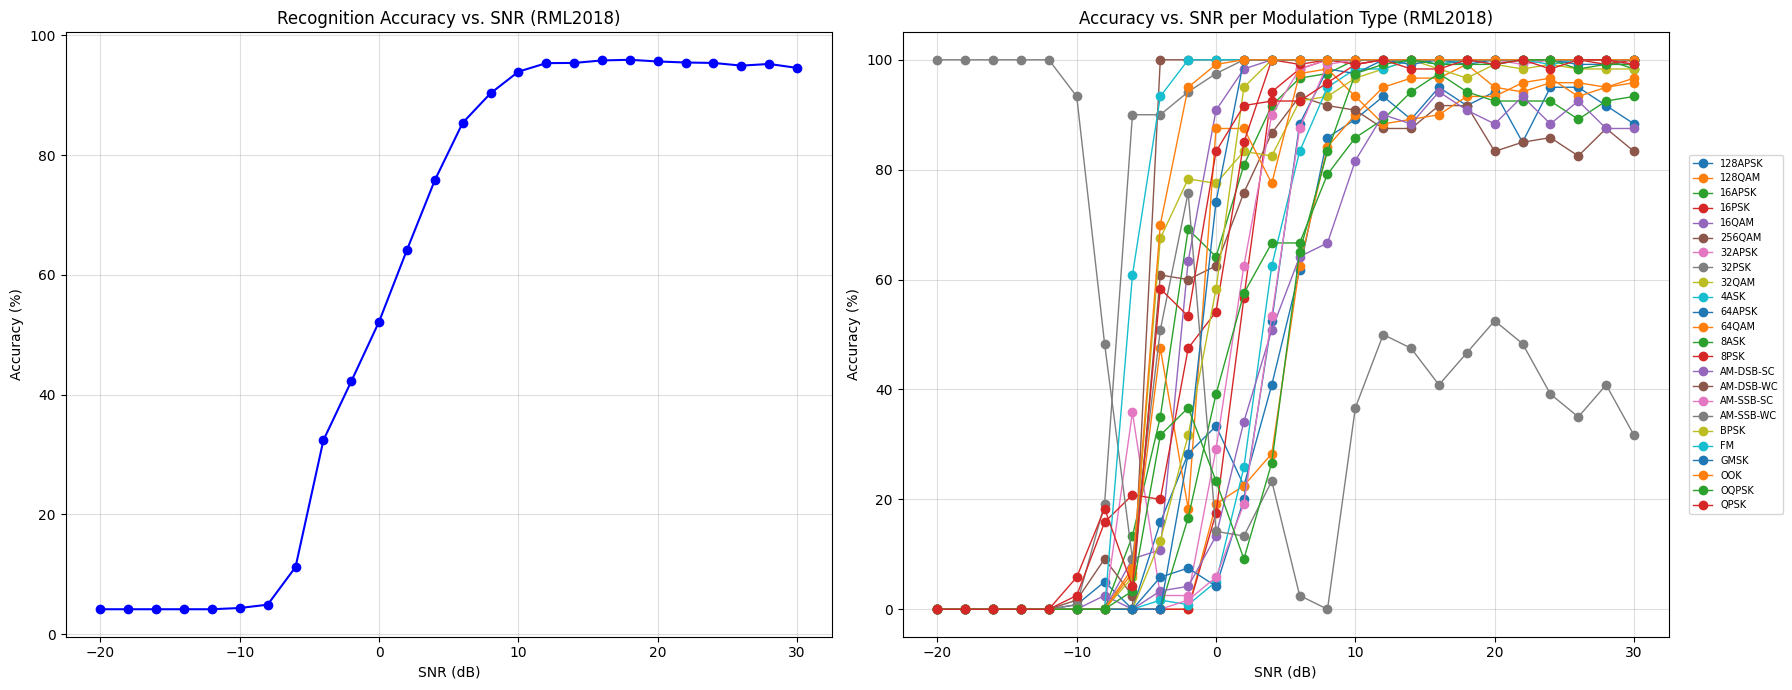

In [3]:
# Cell 3: TEST - RML2018 model evaluation
# https://www.kaggle.com/jacobramey
# https://github.com/rameyjm7

from pathlib import Path
import ast
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import json
from tensorflow.keras.models import load_model

# --------------------------------------------------------------
# Resolve paths and config
# --------------------------------------------------------------
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    cfg = yaml.safe_load(cfg_path.read_text())
    dcfg = cfg.get('datasets', {}).get('rml2018', {})
    h5_path = Path(dcfg.get('hdf5', '/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5'))
    classes_path = Path(dcfg.get('classes', '/scratch/rameyjm7/datasets/RML2018/classes.txt'))
    classes_fixed_path = Path(dcfg.get('classes_fixed', '/scratch/rameyjm7/datasets/RML2018/classes-fixed.txt'))
else:
    h5_path = Path('/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5')
    classes_path = Path('/scratch/rameyjm7/datasets/RML2018/classes.txt')
    classes_fixed_path = Path('/scratch/rameyjm7/datasets/RML2018/classes-fixed.txt')

best_ckpt_txt = project_root / 'models' / 'rml2018' / 'checkpoints' / 'best_checkpoint.txt'
default_model_path = project_root / 'models' / 'rml2018' / 'rml2018_lstm_rnn.keras'
if best_ckpt_txt.exists():
    cand = Path(best_ckpt_txt.read_text().strip())
    model_path = cand if cand.exists() else default_model_path
else:
    model_path = default_model_path

print('RML2018 dataset:', h5_path)
print('RML2018 model:', model_path)
outputs_dir_50 = project_root / 'outputs' / '50_evaluation_comparison'
outputs_dir_50.mkdir(parents=True, exist_ok=True)
print('Outputs dir:', outputs_dir_50)

assert h5_path.exists(), f'Missing dataset: {h5_path}'
assert classes_path.exists(), f'Missing classes file: {classes_path}'
assert classes_fixed_path.exists(), f'Missing classes-fixed file: {classes_fixed_path}'
assert model_path.exists(), f'Missing model: {model_path}'

# --------------------------------------------------------------
# Build highest-SNR class-balanced eval split
# --------------------------------------------------------------
def parse_classes(path: Path):
    text = path.read_text()
    match = re.search(r'classes\s*=\s*(\[[\s\S]*?\])', text)
    if not match:
        raise ValueError(f'Could not parse classes from {path}')
    return ast.literal_eval(match.group(1))

classes_orig = parse_classes(classes_path)
classes_fixed = parse_classes(classes_fixed_path)
remap_fixed = np.array([classes_fixed.index(c) for c in classes_orig], dtype=np.int64)

with h5py.File(h5_path, 'r') as h5:
    X = h5['X']
    Y = h5['Y']
    Z = h5['Z']

    snr = Z[:, 0]
    max_snr = int(np.max(snr))
    max_idx = np.where(snr == max_snr)[0]
    y_max = np.argmax(Y[max_idx], axis=1)

    rng = np.random.default_rng(42)
    picked = []
    for cls in np.unique(y_max):
        cls_idx = max_idx[y_max == cls]
        k = min(200, len(cls_idx))
        picked.extend(rng.choice(cls_idx, size=k, replace=False).tolist())

    picked = np.array(sorted(picked), dtype=np.int64)
    x_iq = np.asarray(X[picked], dtype=np.float32)
    y_orig = np.argmax(np.asarray(Y[picked]), axis=1).astype(np.int64)
    snr_vals = np.asarray(Z[picked, 0], dtype=np.float32)

# Build alternate target encodings
y_fixed = remap_fixed[y_orig]
y_names = np.array([classes_orig[i] for i in y_orig])
le = LabelEncoder()
y_le = le.fit_transform(y_names)
classes_le = list(le.classes_)

snr_ch = np.repeat(snr_vals[:, None, None], x_iq.shape[1], axis=1)
X_eval = np.concatenate([x_iq, snr_ch], axis=2).astype(np.float32)

print('X_eval shape:', X_eval.shape)
print('max_snr used:', max_snr)

# --------------------------------------------------------------
# Evaluate model with automatic label-order calibration
# --------------------------------------------------------------
model = load_model(model_path, compile=False)
y_pred = np.argmax(model.predict(X_eval, verbose=0), axis=1)

acc_orig = accuracy_score(y_orig, y_pred)
acc_fixed = accuracy_score(y_fixed, y_pred)
acc_le = accuracy_score(y_le, y_pred)

candidates = [
    ('classes', y_orig, classes_orig, acc_orig),
    ('classes-fixed', y_fixed, classes_fixed, acc_fixed),
    ('labelencoder', y_le, classes_le, acc_le),
]
order_name, y_true, target_names, acc = max(candidates, key=lambda t: t[3])

print(f'RML2018 mapping calibration: acc_orig={acc_orig:.4f}, acc_fixed={acc_fixed:.4f}, acc_le={acc_le:.4f}')
print('Using mapping:', order_name)
print(f'RML2018 evaluation accuracy: {acc:.4f}')
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(target_names)))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title(f'Confusion Matrix (RML2018, mapping={order_name})')
plt.xlabel('Predicted class index')
plt.ylabel('True class index')
plt.tight_layout()
cm_png = outputs_dir_50 / '50_rml2018_confusion_matrix.png'
plt.savefig(cm_png, dpi=180)
print('Saved confusion matrix:', cm_png)
plt.show()

# Optional: load and plot continuation training curves from outputs/rml2018
history_dir = project_root / 'outputs' / 'rml2018'
history_files = sorted(history_dir.glob('*.history.json'))
if history_files:
    latest_hist = max(history_files, key=lambda p: p.stat().st_mtime)
    print('Using history file:', latest_hist)
    hist = json.loads(latest_hist.read_text())
    acc_h = hist.get('accuracy', [])
    val_acc_h = hist.get('val_accuracy', [])
    loss_h = hist.get('loss', [])
    val_loss_h = hist.get('val_loss', [])

    if acc_h and val_acc_h and loss_h and val_loss_h:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(acc_h, label='train_accuracy')
        plt.plot(val_acc_h, label='val_accuracy')
        plt.title(f'Continuation Accuracy ({len(acc_h)} epochs)')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(loss_h, label='train_loss')
        plt.plot(val_loss_h, label='val_loss')
        plt.title(f'Continuation Loss ({len(loss_h)} epochs)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        curves_png = outputs_dir_50 / '50_rml2018_continuation_training_curves.png'
        plt.savefig(curves_png, dpi=180)
        print('Saved training curves:', curves_png)
        plt.show()



# --------------------------------------------------------------
# Build broader per-SNR slice and plot line charts (RML2018)
# --------------------------------------------------------------
MAX_PER_CLASS_PER_SNR = 120

X_rows, y_rows, snr_rows = [], [], []
with h5py.File(h5_path, 'r') as h5:
    X_all = h5['X']
    Y_all = h5['Y']
    Z_all = h5['Z']

    buckets = {}
    for i in range(len(X_all)):
        s = int(Z_all[i, 0])
        cls = int(np.argmax(Y_all[i]))
        key = (cls, s)
        buckets.setdefault(key, 0)
        if buckets[key] >= MAX_PER_CLASS_PER_SNR:
            continue
        buckets[key] += 1

        iq = np.asarray(X_all[i], dtype=np.float32)
        snr_col = np.full((iq.shape[0], 1), s, dtype=np.float32)
        X_rows.append(np.concatenate([iq, snr_col], axis=1))
        y_rows.append(cls)
        snr_rows.append(s)

X_snr = np.asarray(X_rows, dtype=np.float32)
y_snr_orig = np.asarray(y_rows, dtype=np.int64)
snr_vals = np.asarray(snr_rows, dtype=np.int64)
if order_name == 'classes-fixed':
    y_snr = remap_fixed[y_snr_orig]
    snr_target_names = classes_fixed
elif order_name == 'labelencoder':
    y_snr_names = np.array([classes_orig[i] for i in y_snr_orig])
    y_snr = le.transform(y_snr_names)
    snr_target_names = classes_le
else:
    y_snr = y_snr_orig
    snr_target_names = classes_orig

y_snr_pred = np.argmax(model.predict(X_snr, verbose=0), axis=1)
unique_snrs = np.array(sorted(np.unique(snr_vals)), dtype=int)

overall_acc = []
per_mod_acc = np.full((len(snr_target_names), len(unique_snrs)), np.nan, dtype=np.float32)
for j, s in enumerate(unique_snrs):
    idx = np.where(snr_vals == s)[0]
    overall_acc.append(float(np.mean(y_snr_pred[idx] == y_snr[idx])) * 100.0)

for c in range(len(snr_target_names)):
    cls_mask = y_snr == c
    for j, s in enumerate(unique_snrs):
        idx = np.where((snr_vals == s) & cls_mask)[0]
        if len(idx) > 0:
            per_mod_acc[c, j] = float(np.mean(y_snr_pred[idx] == y_snr[idx])) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].plot(unique_snrs, overall_acc, marker='o', color='blue')
axes[0].set_title('Recognition Accuracy vs. SNR (RML2018)')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(True, alpha=0.4)

for i, mod in enumerate(snr_target_names):
    axes[1].plot(unique_snrs, per_mod_acc[i], marker='o', linewidth=1.0, label=mod)
axes[1].set_title('Accuracy vs. SNR per Modulation Type (RML2018)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7)
plt.tight_layout()

png = outputs_dir_50 / '50_rml2018_accuracy_vs_snr_line_plots.png'
plt.savefig(png, dpi=180)
print('Saved line charts:', png)
plt.show()




Saved comparison CSV: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_cross_dataset_model_comparison.csv
Saved comparison JSON: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_cross_dataset_model_comparison.json


,dataset,model_name,model_family,split,eval_accuracy,eval_macro_f1,eval_weighted_f1,source,notes
0,deepradar2022,cnn_transformer_deepradar2022_continued_stage2,cnn_transformer,all_test,0.446100,0.397279,0.397279,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 33 DeepRadar artifact
1,noisy_drone_rf_v2,noisy_drone_rf_v2_vgg_full_complex_spectrogram,vgg_full_complex_spectrogram,balanced_test,0.970110,0.970515,0.970515,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 44 metrics
2,noisy_drone_rf_v2,noisy_drone_rf_v2_vgg_full_complex_spectrogram,vgg_full_complex_spectrogram,natural_test,0.970110,0.970515,0.970515,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 44 metrics
3,rml2016,cnn_transformer,cnn_transformer,all_test,0.664477,0.659152,0.659152,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 33 comparison artifact
4,rml2016,lstm_teacher,lstm_teacher,all_test,0.588114,0.632495,0.632495,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 33 comparison artifact
5,rml2016,cnn_transformer,cnn_transformer,test_snr_gt_-2db,0.896910,0.890028,0.891263,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Notebook 33 comparison artifact
6,rml2018,rml2018_lstm_continued_500_20260413_235547,lstm,all_test,0.829514,NaN,NaN,/home/rameyjm7/workspace/ML-wireless-signal-cl...,Best checkpoint by eval_accuracy


Saved comparison plot: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_cross_dataset_model_comparison_accuracy.png


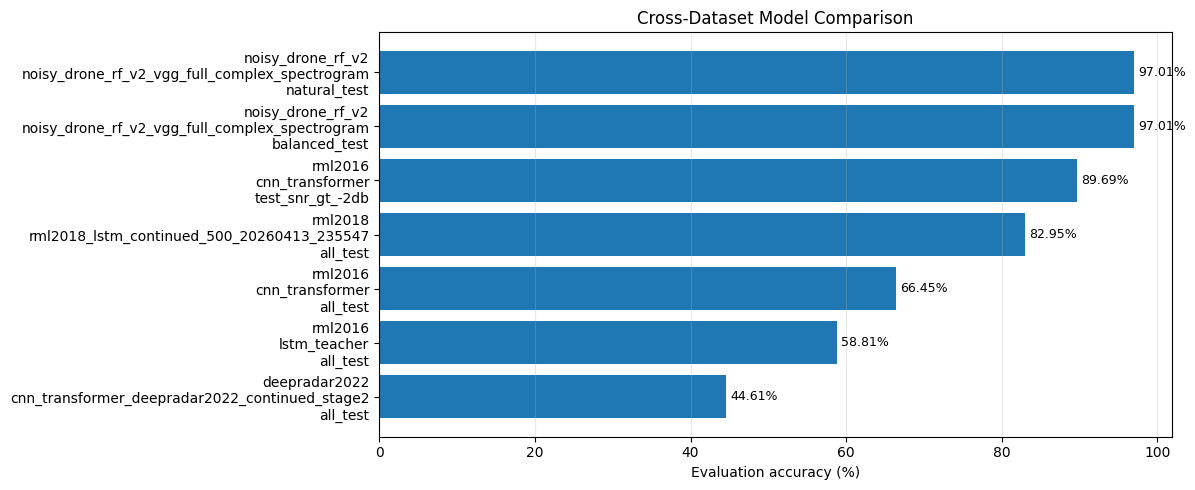

Saved standalone artifact index: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/50_evaluation_comparison/50_final_standalone_figure_artifacts.csv


,artifact,path,exists
0,cross_dataset_accuracy_summary,/home/rameyjm7/workspace/ML-wireless-signal-cl...,True
1,noisy_drone_balanced_confusion_matrix,/home/rameyjm7/workspace/ML-wireless-signal-cl...,True
2,noisy_drone_accuracy_vs_snr,/home/rameyjm7/workspace/ML-wireless-signal-cl...,True
3,noisy_drone_accuracy_vs_snr_per_class,/home/rameyjm7/workspace/ML-wireless-signal-cl...,True


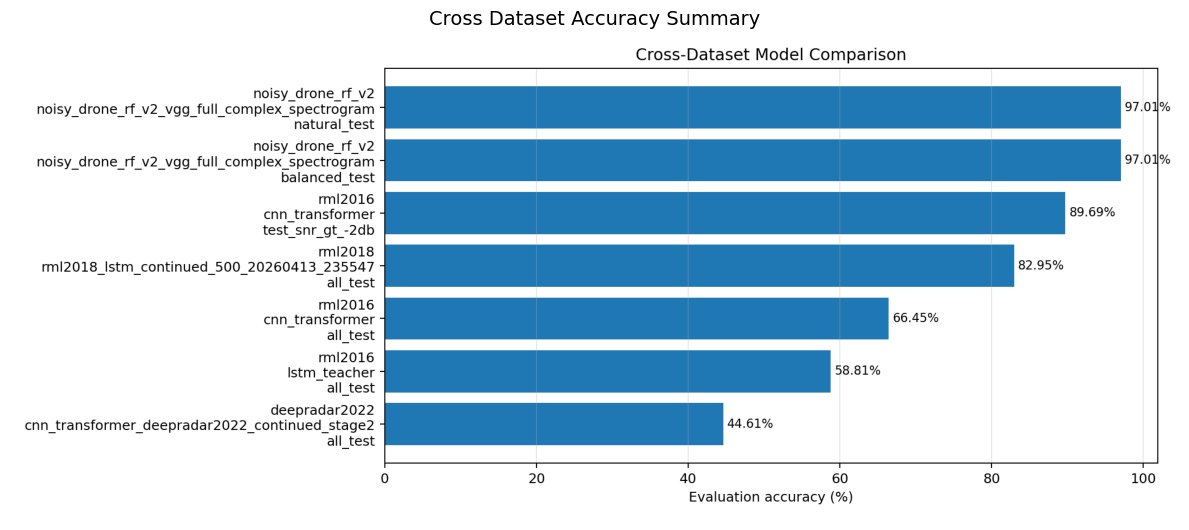

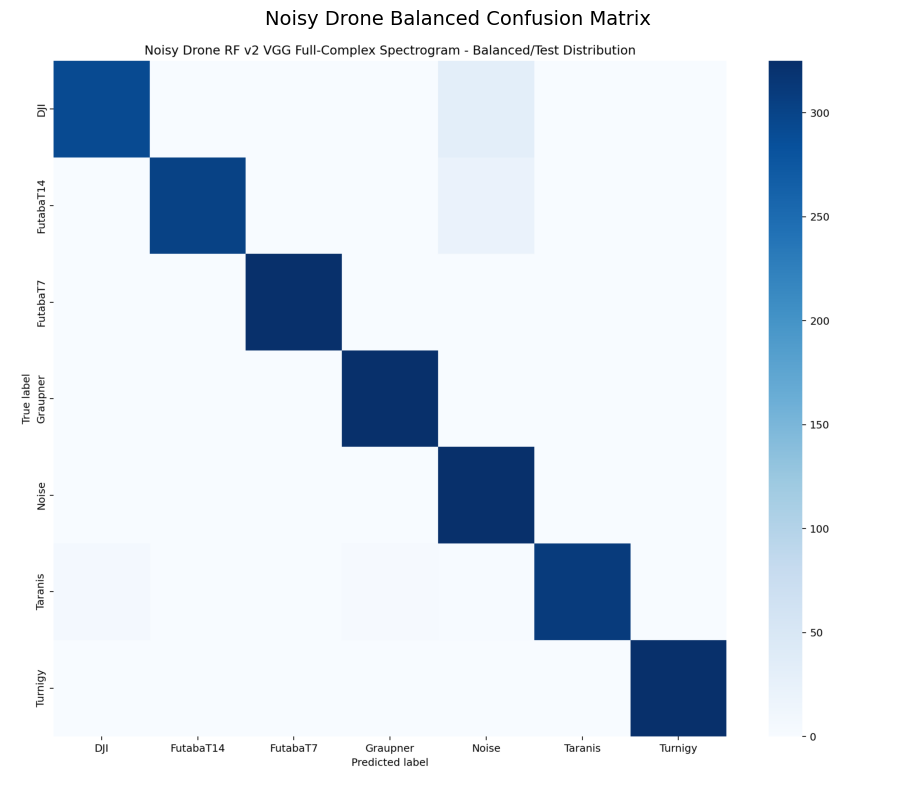

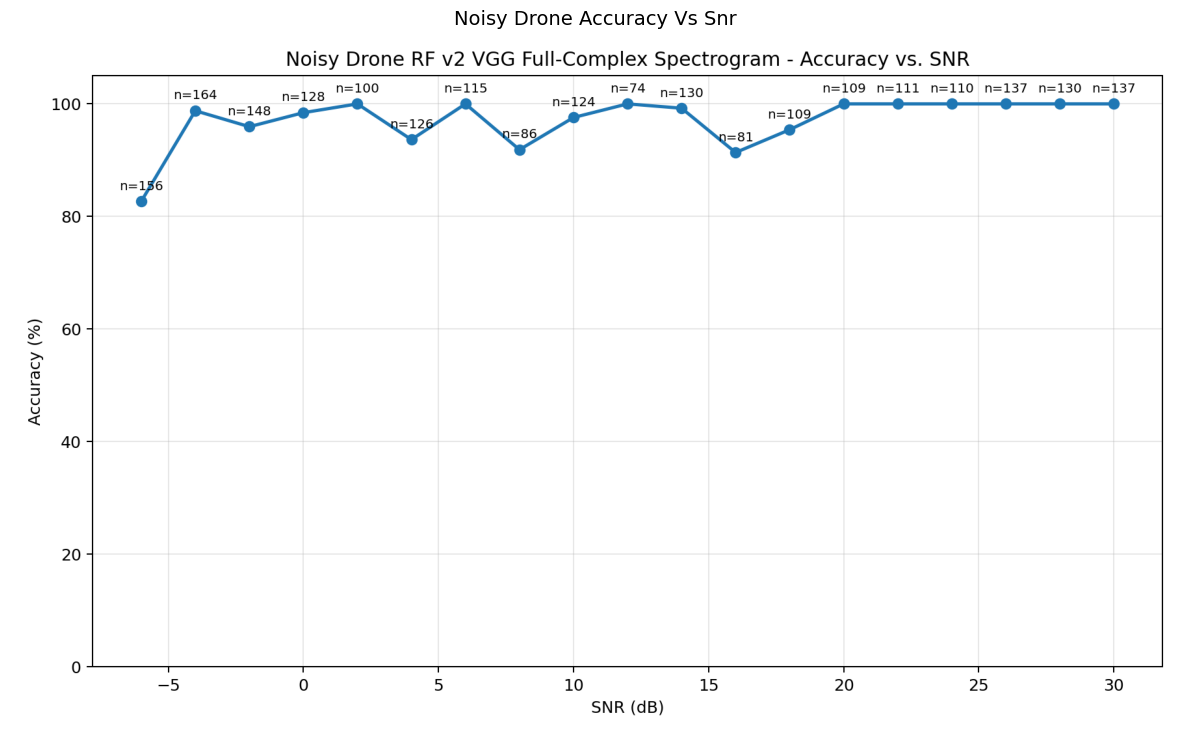

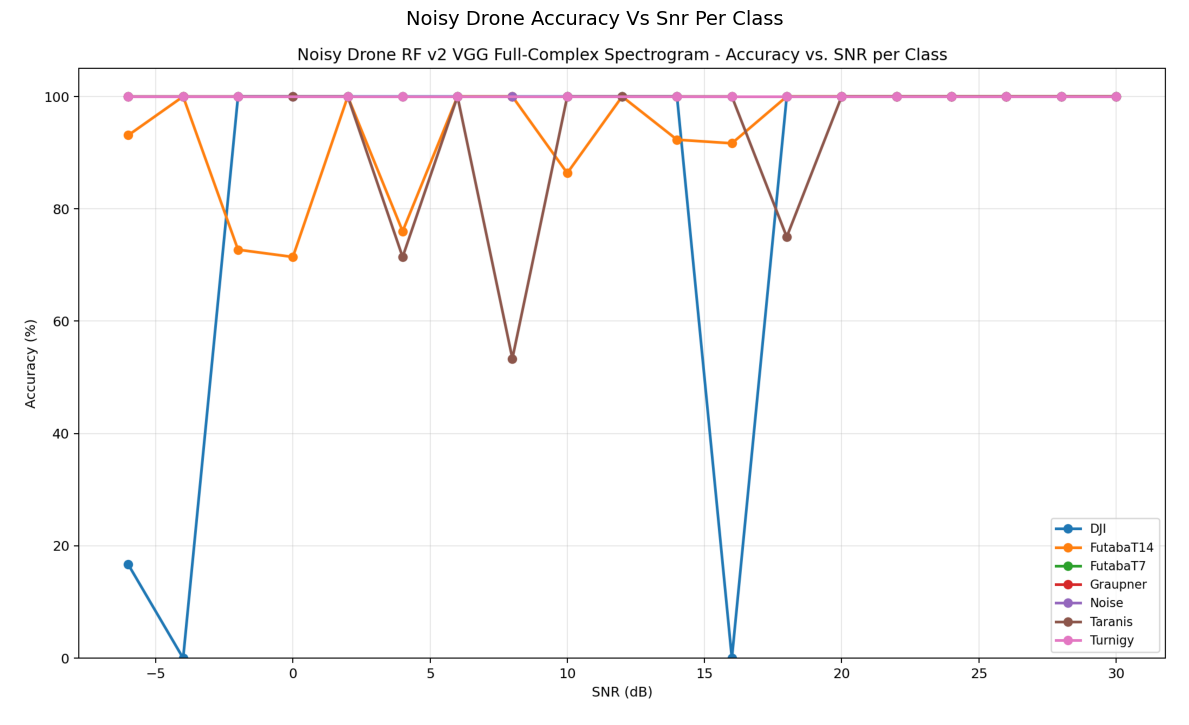

Standalone final figures displayed separately; no composite image generated.


In [4]:
# Cell 4: TEST - Cross-dataset model comparison, including Noisy Drone RF v2 from notebook 44
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
outputs_dir_50 = project_root / 'outputs' / '50_evaluation_comparison'
outputs_dir_50.mkdir(parents=True, exist_ok=True)


def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text())
    except Exception as exc:
        print(f'Could not read {path}: {exc}')
        return None


def add_row(rows, dataset, model_name, model_family, source, split='all_test', accuracy=None, macro_f1=None, weighted_f1=None, notes=''):
    rows.append({
        'dataset': dataset,
        'model_name': model_name,
        'model_family': model_family,
        'split': split,
        'eval_accuracy': accuracy,
        'eval_macro_f1': macro_f1,
        'eval_weighted_f1': weighted_f1,
        'source': str(source),
        'notes': notes,
    })

rows = []

# RML2016 comparison artifacts from notebook 33.
rml2016_path = project_root / 'outputs' / 'rml2016' / 'rml2016_cnn_transformer_comparison.json'
rml2016_rows = read_json(rml2016_path)
if isinstance(rml2016_rows, list):
    for item in rml2016_rows:
        add_row(
            rows,
            dataset='rml2016',
            model_name=item.get('model', 'unknown'),
            model_family=item.get('model', 'unknown'),
            split=item.get('split', 'unknown'),
            accuracy=item.get('accuracy'),
            macro_f1=item.get('macro_f1'),
            weighted_f1=item.get('weighted_f1'),
            source=rml2016_path,
            notes='Notebook 33 comparison artifact',
        )

# RML2018 best checkpoint artifact from notebook 31/41.
rml2018_path = project_root / 'outputs' / 'rml2018' / 'rml2018_checkpoint_metrics.json'
rml2018_rows = read_json(rml2018_path)
if isinstance(rml2018_rows, list) and rml2018_rows:
    best = max(rml2018_rows, key=lambda row: row.get('eval_accuracy', float('-inf')))
    add_row(
        rows,
        dataset='rml2018',
        model_name=Path(best.get('checkpoint', 'rml2018_lstm_rnn')).stem,
        model_family='lstm',
        split='all_test',
        accuracy=best.get('eval_accuracy'),
        macro_f1=None,
        weighted_f1=None,
        source=rml2018_path,
        notes='Best checkpoint by eval_accuracy',
    )

# DeepRadar2022 artifact from CNN-transformer experiments if present.
deepradar_path = project_root / 'outputs' / 'deepradar2022' / 'deepradar2022_cnn_transformer_stage2_result.json'
deepradar = read_json(deepradar_path)
if isinstance(deepradar, dict):
    add_row(
        rows,
        dataset='deepradar2022',
        model_name=deepradar.get('model', 'deepradar2022_cnn_transformer'),
        model_family='cnn_transformer',
        split=deepradar.get('split', 'all_test'),
        accuracy=deepradar.get('accuracy'),
        macro_f1=deepradar.get('macro_f1'),
        weighted_f1=deepradar.get('weighted_f1'),
        source=deepradar_path,
        notes='Notebook 33 DeepRadar artifact',
    )

# Noisy Drone RF v2: prefer notebook 44 metrics, fallback to notebook 33 metrics.
noisy_44_path = project_root / 'outputs' / 'noisy_drone_rf_v2_eval' / '44_noisy_drone_rf_v2_vgg_full_complex_spectrogram_metrics.json'
noisy_33_path = project_root / 'outputs' / 'noisy_drone_rf_v2_eval' / '33_noisy_drone_rf_v2_vgg_full_complex_spectrogram_metrics.json'
noisy_path = noisy_44_path if noisy_44_path.exists() else noisy_33_path
noisy = read_json(noisy_path)
if isinstance(noisy, dict):
    model_name = noisy.get('model', 'noisy_drone_rf_v2_vgg_full_complex_spectrogram')
    add_row(
        rows,
        dataset='noisy_drone_rf_v2',
        model_name=model_name,
        model_family='vgg_full_complex_spectrogram',
        split='natural_test',
        accuracy=noisy.get('natural_accuracy', noisy.get('accuracy')),
        macro_f1=noisy.get('natural_macro_f1', noisy.get('macro_f1')),
        weighted_f1=noisy.get('natural_weighted_f1', noisy.get('weighted_f1')),
        source=noisy_path,
        notes='Notebook 44 metrics' if noisy_path == noisy_44_path else 'Notebook 33 metrics fallback; rerun 44 to refresh',
    )
    if 'balanced_accuracy' in noisy:
        add_row(
            rows,
            dataset='noisy_drone_rf_v2',
            model_name=model_name,
            model_family='vgg_full_complex_spectrogram',
            split='balanced_test',
            accuracy=noisy.get('balanced_accuracy'),
            macro_f1=noisy.get('balanced_macro_f1'),
            weighted_f1=noisy.get('balanced_weighted_f1'),
            source=noisy_path,
            notes='Notebook 44 metrics' if noisy_path == noisy_44_path else 'Notebook 33 metrics fallback; rerun 44 to refresh',
        )

comparison_df = pd.DataFrame(rows)
if comparison_df.empty:
    raise FileNotFoundError('No comparison metrics found. Run/evaluate notebooks 33/41/44 first.')

for col in ['eval_accuracy', 'eval_macro_f1', 'eval_weighted_f1']:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')

comparison_df = comparison_df.sort_values(['dataset', 'split', 'eval_accuracy'], ascending=[True, True, False]).reset_index(drop=True)
comparison_csv = outputs_dir_50 / '50_cross_dataset_model_comparison.csv'
comparison_json = outputs_dir_50 / '50_cross_dataset_model_comparison.json'
comparison_df.to_csv(comparison_csv, index=False)
comparison_json.write_text(comparison_df.to_json(orient='records', indent=2), encoding='utf-8')
print('Saved comparison CSV:', comparison_csv)
print('Saved comparison JSON:', comparison_json)
display(comparison_df)

plot_df = comparison_df.dropna(subset=['eval_accuracy']).copy()
plot_df['label'] = plot_df['dataset'] + '\n' + plot_df['model_name'] + '\n' + plot_df['split']
plot_df = plot_df.sort_values('eval_accuracy')

fig_height = max(5, 0.5 * len(plot_df))
fig, ax = plt.subplots(figsize=(12, fig_height))
ax.barh(plot_df['label'], plot_df['eval_accuracy'] * 100.0)
ax.set_xlabel('Evaluation accuracy (%)')
ax.set_title('Cross-Dataset Model Comparison')
ax.grid(True, axis='x', alpha=0.3)
for idx, value in enumerate(plot_df['eval_accuracy'] * 100.0):
    ax.text(value + 0.5, idx, f'{value:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plot_path = outputs_dir_50 / '50_cross_dataset_model_comparison_accuracy.png'
plt.savefig(plot_path, dpi=180)
print('Saved comparison plot:', plot_path)
plt.show()



# Report final standalone figure artifacts instead of compositing them into one image.
standalone_artifacts = {
    'cross_dataset_accuracy_summary': outputs_dir_50 / '50_cross_dataset_model_comparison_accuracy.png',
    'noisy_drone_balanced_confusion_matrix': project_root / 'outputs' / 'noisy_drone_rf_v2_eval' / '44_noisy_drone_rf_v2_vgg_full_complex_spectrogram_balanced_confusion_matrix.png',
    'noisy_drone_accuracy_vs_snr': project_root / 'outputs' / 'noisy_drone_rf_v2_eval' / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr.png',
    'noisy_drone_accuracy_vs_snr_per_class': project_root / 'outputs' / 'noisy_drone_rf_v2_eval' / '44_noisy_drone_rf_v2_vgg_full_complex_accuracy_vs_snr_per_class.png',
}

artifact_rows = []
for name, path in standalone_artifacts.items():
    artifact_rows.append({
        'artifact': name,
        'path': str(path),
        'exists': path.exists(),
    })
artifact_df = pd.DataFrame(artifact_rows)
artifact_csv = outputs_dir_50 / '50_final_standalone_figure_artifacts.csv'
artifact_df.to_csv(artifact_csv, index=False)
print('Saved standalone artifact index:', artifact_csv)
display(artifact_df)

missing = artifact_df[~artifact_df['exists']]
if not missing.empty:
    print('Missing artifacts. Run notebook 44 Cells 3-4 and this Cell 4 again if needed.')
else:
    from matplotlib.image import imread

    for name, path in standalone_artifacts.items():
        img = imread(path)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.set_title(name.replace('_', ' ').title(), fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    print('Standalone final figures displayed separately; no composite image generated.')
